# 03. Walk-forward 검증

## 왜 필요한가

02번은 **단일 분할**(train ~2024 / valid 2025 / test 2026)로 재서, 모델이 naive
대비 2~6% 나았다(미나리만 -24.1%). 그런데 같은 노트북에서 배추는
**valid 13.78% vs test 7.45%** 였다. **연도 변동이 개선폭보다 크다**는 뜻이다.

그러면 02번의 결론이 실력인지 2026년이 우연히 쉬웠던 건지 구분되지 않는다.
여기서는 시점을 옮겨가며 여러 번 재서 **개선이 일관적인지**를 본다.

## 설계

**확장 창(expanding window)** 을 쓴다. 폴드마다 그 시점까지의 과거 전부로
학습하고 다음 6개월을 예측한다. 실제 운영(오늘까지 배워서 다음 구간을 맞힘)과
같은 구조다. 고정 창(최근 N년만)도 가능하지만, 표본이 품목당 1,371일로 적어
버릴 여유가 없다.

- 폴드 7개: 2023H1 · 2023H2 · 2024H1 · 2024H2 · 2025H1 · 2025H2 · 2026(1~8월)
- 첫 폴드도 학습에 2년(2021~2022)을 확보한다
- 각 폴드 경계에 embargo — 타깃이 `t+7` 을 보므로 그만큼 잘라낸다

**하이퍼파라미터는 02번 값으로 고정한다.** 폴드마다 튜닝하면 그 자체가 미래를
보는 셈이고, 지금 확인하려는 건 성능 극대화가 아니라 **개선의 일관성**이다.

피처 생성 함수는 02번과 같은 로직을 다시 정의한다. 아직 피처 설계가 확정 전이라
모듈로 굳히기 이르다 — 세 번째로 같은 코드를 쓰게 되면 그때 패키지로 뺀다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingRegressor

_available = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _available:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())

H = 7
EXO = ["temp_avg", "temp_min", "temp_max", "precip_mm_avg", "precip_mm_max",
       "humidity_avg", "sunshine_hr_avg", "shipment_qty", "shipment_qty_w1ago"]
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]


def build(src, h=H):
    """02번과 동일. 가격 피처는 t 까지만, 외생변수는 shift(1), 달력은 그대로."""
    d = src.copy()
    d["_logp"] = np.log(d.price_kg_avg)

    def g(col):
        return d.groupby("item")[col]

    d["y"] = g("_logp").shift(-h) - d._logp
    for lag in (1, 2, 3, 5, 10, 20):
        d[f"ret{lag}"] = d._logp - g("_logp").shift(lag)
    for w in (5, 20, 60):
        mp = max(2, w // 3)
        d[f"dev{w}"] = d._logp - g("_logp").transform(
            lambda s: s.rolling(w, min_periods=mp).mean())
        d[f"vol{w}"] = g("_logp").transform(
            lambda s: s.diff().rolling(w, min_periods=mp).std())
    for c in EXO:
        d[f"{c}_l1"] = g(c).shift(1)
        d[f"{c}_d20"] = d[f"{c}_l1"] - g(c).transform(
            lambda s: s.shift(1).rolling(20, min_periods=7).mean())
    d["item_code"] = pd.Categorical(d.item, categories=items).codes
    return d


FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)]
         + [f"dev{w}" for w in (5, 20, 60)] + [f"vol{w}" for w in (5, 20, 60)]
         + [f"{c}_l1" for c in EXO] + [f"{c}_d20" for c in EXO]
         + CAL + ["item_code"])
CAT_IDX = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]

feat = build(df).dropna(subset=["y"])
print(f"{len(feat):,}행 | 피처 {len(FEATS)}개")

8,178행 | 피처 36개


## 1. 폴드 실행

각 폴드에서:

1. `train` = 데이터 시작 ~ (test 시작 - embargo)
2. `test` = 그 6개월
3. naive(`y_hat=0`)와 모델을 같은 test 에서 비교

**embargo 를 두는 이유**: 타깃이 `t+7` 거래일을 보므로, train 끝자락 행들의 정답은
test 구간에 걸쳐 있다. 그대로 두면 모델이 test 기간의 가격을 간접적으로 본다.

In [2]:
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
EMBARGO = pd.Timedelta(days=int(H * 1.5))

PARAMS = dict(loss="absolute_error", max_iter=400, learning_rate=0.05,
              max_leaf_nodes=15, min_samples_leaf=40, l2_regularization=1.0,
              categorical_features=CAT_IDX, early_stopping=False, random_state=42)


def mape(part, y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    actual = part.price_kg_avg.values * np.exp(part.y.values)
    pred = part.price_kg_avg.values * np.exp(y_pred)
    return pd.Series(np.abs(pred - actual) / actual, index=part.index) \
             .groupby(part.item).mean() * 100


rows = []
for s, e in FOLDS:
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    tr = feat[feat.price_date < s - EMBARGO]
    te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
    if te.empty:
        continue
    m = HistGradientBoostingRegressor(**PARAMS).fit(tr[FEATS], tr.y)
    nv, md = mape(te, np.zeros(len(te))), mape(te, m.predict(te[FEATS]))
    label = f"{s:%Y}H{1 if s.month < 7 else 2}"
    for it in items:
        rows.append({"fold": label, "item": it, "naive": nv[it], "model": md[it],
                     "개선%": (md[it] / nv[it] - 1) * 100})
    print(f"{label}  train {len(tr):>5,} / test {len(te):>4,}  "
          f"({tr.price_date.min():%Y-%m}~{tr.price_date.max():%Y-%m} -> {s:%Y-%m}~{te.price_date.max():%Y-%m})")

wf = pd.DataFrame(rows)
print(f"\n폴드 {wf.fold.nunique()}개 × 품목 {wf.item.nunique()}개 = {len(wf)}건")

2023H1  train 2,922 / test  732  (2021-01~2022-12 -> 2023-01~2023-06)


2023H2  train 3,648 / test  732  (2021-01~2023-06 -> 2023-07~2023-12)


2024H1  train 4,398 / test  726  (2021-01~2023-12 -> 2024-01~2024-06)


2024H2  train 5,118 / test  738  (2021-01~2024-06 -> 2024-07~2024-12)


2025H1  train 5,856 / test  708  (2021-01~2024-12 -> 2025-01~2025-06)


2025H2  train 6,564 / test  744  (2021-01~2025-06 -> 2025-07~2025-12)


2026H1  train 7,302 / test  834  (2021-01~2025-12 -> 2026-01~2026-07)

폴드 7개 × 품목 6개 = 42건


## 2. 개선이 일관적인가

보는 법:

- **음수 = naive 보다 나음.** 칸이 전부 파랗다면 일관된 개선이다.
- 부호가 폴드마다 뒤집히면 그 품목은 **모델을 쓸 근거가 없다.**
- 02번의 단일 분할 결과(맨 오른쪽 2026 열)가 다른 폴드와 크게 다르면,
  그 결론은 그 구간이 특이했던 것이다.

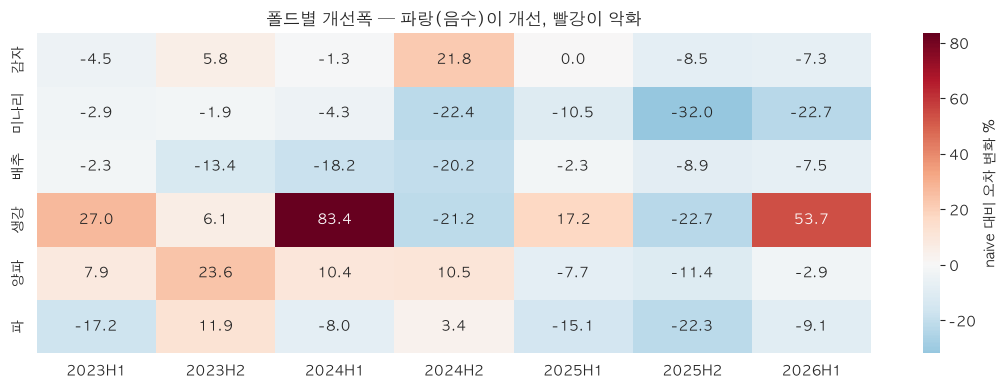

fold,2023H1,2023H2,2024H1,2024H2,2025H1,2025H2,2026H1
item,,,,,,,
감자,-4.5,5.8,-1.3,21.8,0.0,-8.5,-7.3
미나리,-2.9,-1.9,-4.3,-22.4,-10.5,-32.0,-22.7
배추,-2.3,-13.4,-18.2,-20.2,-2.3,-8.9,-7.5
생강,27.0,6.1,83.4,-21.2,17.2,-22.7,53.7
양파,7.9,23.6,10.4,10.5,-7.7,-11.4,-2.9
파,-17.2,11.9,-8.0,3.4,-15.1,-22.3,-9.1


In [3]:
piv = wf.pivot(index="item", columns="fold", values="개선%")

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(piv, annot=True, fmt=".1f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "naive 대비 오차 변화 %"})
ax.set_title("폴드별 개선폭 — 파랑(음수)이 개선, 빨강이 악화")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(piv.round(1))

,평균개선%,표준편차,최악폴드%,승률,판정
item,,,,,
미나리,-13.81,11.86,-1.93,1.00,쓸 만함
배추,-10.40,7.16,-2.30,1.00,쓸 만함
파,-8.07,12.01,11.88,0.71,쓸 만함
감자,0.85,10.41,21.79,0.57,모델이 해로움
양파,4.34,12.30,23.65,0.43,모델이 해로움
생강,20.50,38.56,83.38,0.29,모델이 해로움


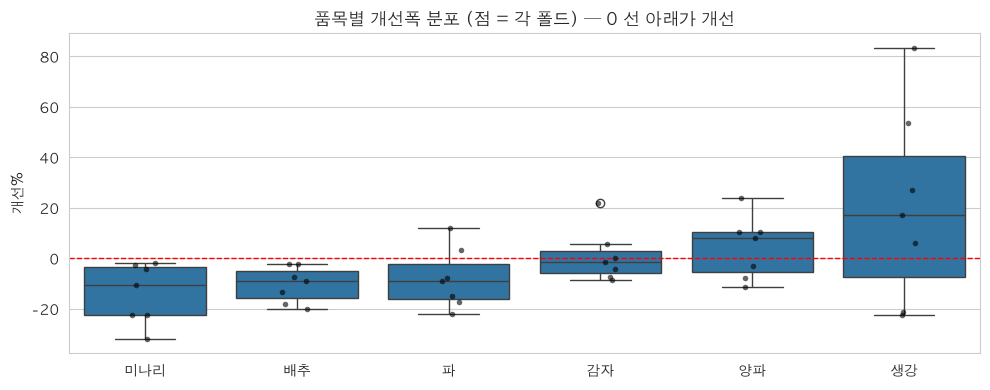

In [4]:
summary = pd.DataFrame({
    "평균개선%": piv.mean(axis=1),
    "표준편차": piv.std(axis=1),
    "최악폴드%": piv.max(axis=1),
    "승률": (piv < 0).mean(axis=1),
}).round(2)
summary["판정"] = np.where(
    (summary["평균개선%"] < 0) & (summary["승률"] >= 0.7), "쓸 만함",
    np.where(summary["평균개선%"] > 0, "모델이 해로움", "불안정"))
order = summary.sort_values("평균개선%").index
display(summary.loc[order])

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=wf, x="item", y="개선%", ax=ax, order=order)
sns.stripplot(data=wf, x="item", y="개선%", ax=ax, color="black", size=4,
              alpha=0.6, order=order)
ax.axhline(0, color="red", ls="--", lw=1)
ax.set_title("품목별 개선폭 분포 (점 = 각 폴드) — 0 선 아래가 개선")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 3. 폴드 간 난이도 차이

개선폭만 보면 모델 탓인지 그 구간이 어려웠던 탓인지 구분이 안 된다.
naive 자체의 오차를 폴드별로 그려 **어느 시기가 원래 어려웠는지** 같이 본다.

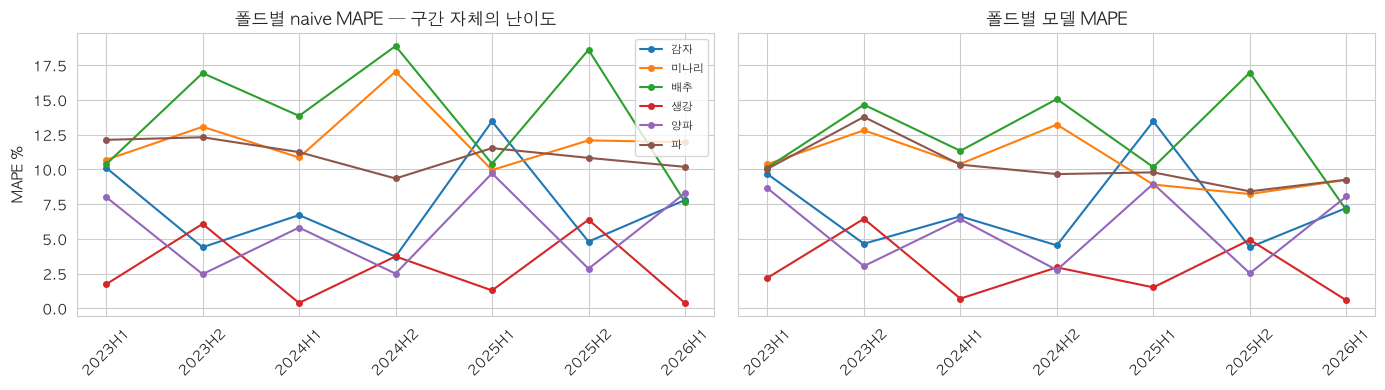

폴드별 naive MAPE 평균(= 그 구간의 난이도):
fold
2023H1    8.83
2023H2    9.20
2024H1    8.14
2024H2    9.20
2025H1    9.39
2025H2    9.25
2026H1    7.70


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for it in items:
    d = wf[wf.item == it]
    axes[0].plot(d.fold, d.naive, marker="o", ms=4, label=it)
    axes[1].plot(d.fold, d.model, marker="o", ms=4, label=it)
axes[0].set_title("폴드별 naive MAPE — 구간 자체의 난이도")
axes[0].set_ylabel("MAPE %")
axes[0].legend(fontsize=8)
axes[1].set_title("폴드별 모델 MAPE")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("폴드별 naive MAPE 평균(= 그 구간의 난이도):")
print(wf.groupby("fold").naive.mean().round(2).to_string())

## 4. 정리

> **주의 (04번에서 정정)**: 아래 판정은 "폴드별 개선 비율의 평균"으로 낸 것인데,
> MAPE 가 이미 백분율이라 이중 정규화가 일어나 오차 수준이 낮은 품목(생강·감자)을
> 잘못 판정했다. 절대 MAPE 로 다시 보면 생강·감자도 모델이 낫다. 04번을 참고할 것.

### 결과 — 7폴드 확장창, 품목별

| 품목 | 평균 개선% | 표준편차 | 최악 폴드 | 승률 | 판정 |
|---|---|---|---|---|---|
| 미나리 | **-13.81** | 11.86 | -1.93 | **7/7** | 모델 사용 |
| 배추 | **-10.40** | 7.16 | -2.30 | **7/7** | 모델 사용 |
| 파 | **-8.07** | 12.01 | +11.88 | 5/7 | 모델 사용 |
| 감자 | +0.85 | 10.41 | +21.79 | 4/7 | **naive 유지** |
| 양파 | +4.34 | 12.30 | +23.65 | 3/7 | **naive 유지** |
| 생강 | +20.50 | 38.56 | +83.38 | 2/7 | **naive 유지** |

(음수가 개선. 승률 = naive 를 이긴 폴드 수)

### 02번의 결론이 뒤집힌 것 — 이게 이 노트북의 요점

**단일 분할이 두 품목을 잘못 판정했다.**

| 품목 | 02번 (2026H1 단일) | walk-forward 평균 | |
|---|---|---|---|
| 감자 | -6.0% (개선) | **+0.85% (해로움)** | 뒤집힘 |
| 양파 | -4.7% (개선) | **+4.34% (해로움)** | 뒤집힘 |
| 배추 | -2.6% (미미) | **-10.40% (2위)** | 과소평가였음 |

감자는 2026H1 에서 -7.3% 였지만 2024H2 에서는 **+21.8%** 다. 양파도 폴드마다
-11.4% ~ +23.6% 로 부호가 뒤집힌다. **02번이 하필 유리한 구간을 봤을 뿐이다.**

반대로 배추는 02번에서 -2.6% 로 미미해 보였는데 2024H1 -18.2%, 2024H2 -20.2%
로 실제로는 꾸준히 좋다. **한 번만 재면 과소평가도 과대평가만큼 쉽게 난다.**

### 2026H1 은 원래 쉬운 구간이었다

폴드별 naive MAPE 평균: 2023H1 8.83 · 2023H2 9.20 · 2024H1 8.14 · 2024H2 9.20 ·
2025H1 9.39 · 2025H2 9.25 · **2026H1 7.70**.

02번의 test 구간이 7개 중 **가장 난이도가 낮았다.** 감자·양파가 거기서만 좋아
보인 것과 무관하지 않다.

### 그래서 무엇을 할 것인가

**품목별로 예측 전략을 나눈다.**

- **미나리·배추·파 → 모델.** 미나리·배추는 7/7 전승이라 근거가 분명하다.
  파는 5/7 이고 최악 폴드가 +11.9% 라 한 단계 약하다.
- **감자·양파·생강 → naive(값 유지).** 평균적으로 모델이 해롭다. 생강은
  01번에서 본 대로 58.2% 의 날이 전일과 값이 같아 애초에 예측할 변동이 없다.

이 분기는 **품목명으로 하드코딩하지 말고** 정체율(전일과 동일 비율)이나
walk-forward 승률 같은 측정값으로 정하는 편이 안전하다. 품목이 늘어나면
같은 판정을 다시 해야 하기 때문이다.

### 남은 불확실성

- **표준편차가 개선폭만큼 크다.** 미나리조차 평균 -13.81% 에 편차 11.86 이다.
  7폴드는 여전히 적고, 폴드당 test 는 6개월(약 730행)뿐이다.
- **파는 경계선이다.** 승률 5/7, 최악 폴드 +11.9%. 쓰더라도 감시가 필요하다.
- 하이퍼파라미터는 02번 값 그대로다. **이제 walk-forward 라는 평가 틀이
  생겼으니** 튜닝을 해도 단일 분할처럼 속지 않는다.
- 2026H1 폴드는 2026-07-29 이후 기상이 결측이다(ASOS 활용신청 만료).

### 다음

1. **품목별 분기 규칙 구현** — 측정값 기반으로
2. **하이퍼파라미터 튜닝** — walk-forward 평균 개선폭을 목표로
3. **감자·양파가 왜 안 되는지** — 이 둘은 계절 진폭이 크고(양파 3월/5월 2.1배)
   수입 물량 영향을 받는 품목이다. 잔차가 특정 시기에 몰리는지 보고,
   그렇다면 관세청 수입량을 붙일 근거가 된다.
